In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

# Select features & target
features = ["pclass", "sex", "fare", "embarked", "age"]
target = "survived"



In [3]:
# Median imputation for "age"
imp_median = SimpleImputer(strategy="median")
titanic["age"] = imp_median.fit_transform(titanic[["age"]]).ravel()

# Most frequent imputation for "embarked"
imp_freq = SimpleImputer(strategy="most_frequent")
titanic["embarked"] = imp_freq.fit_transform(titanic[["embarked"]]).ravel()


In [4]:
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [5]:
X = titanic[features]
y = titanic[target]

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)



In [7]:
# Decision Tree Model

model = DecisionTreeClassifier(max)
model.fit(X_train, y_train)

# Predictions
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)


# Accuracy Results
print("Training accuracy:", accuracy_score(y_train, y_pred_train) * 100, "%")
print("Testing accuracy:", accuracy_score(y_test, y_pred_test) * 100, "%")

Training accuracy: 97.91332263242376 %
Testing accuracy: 77.23880597014924 %


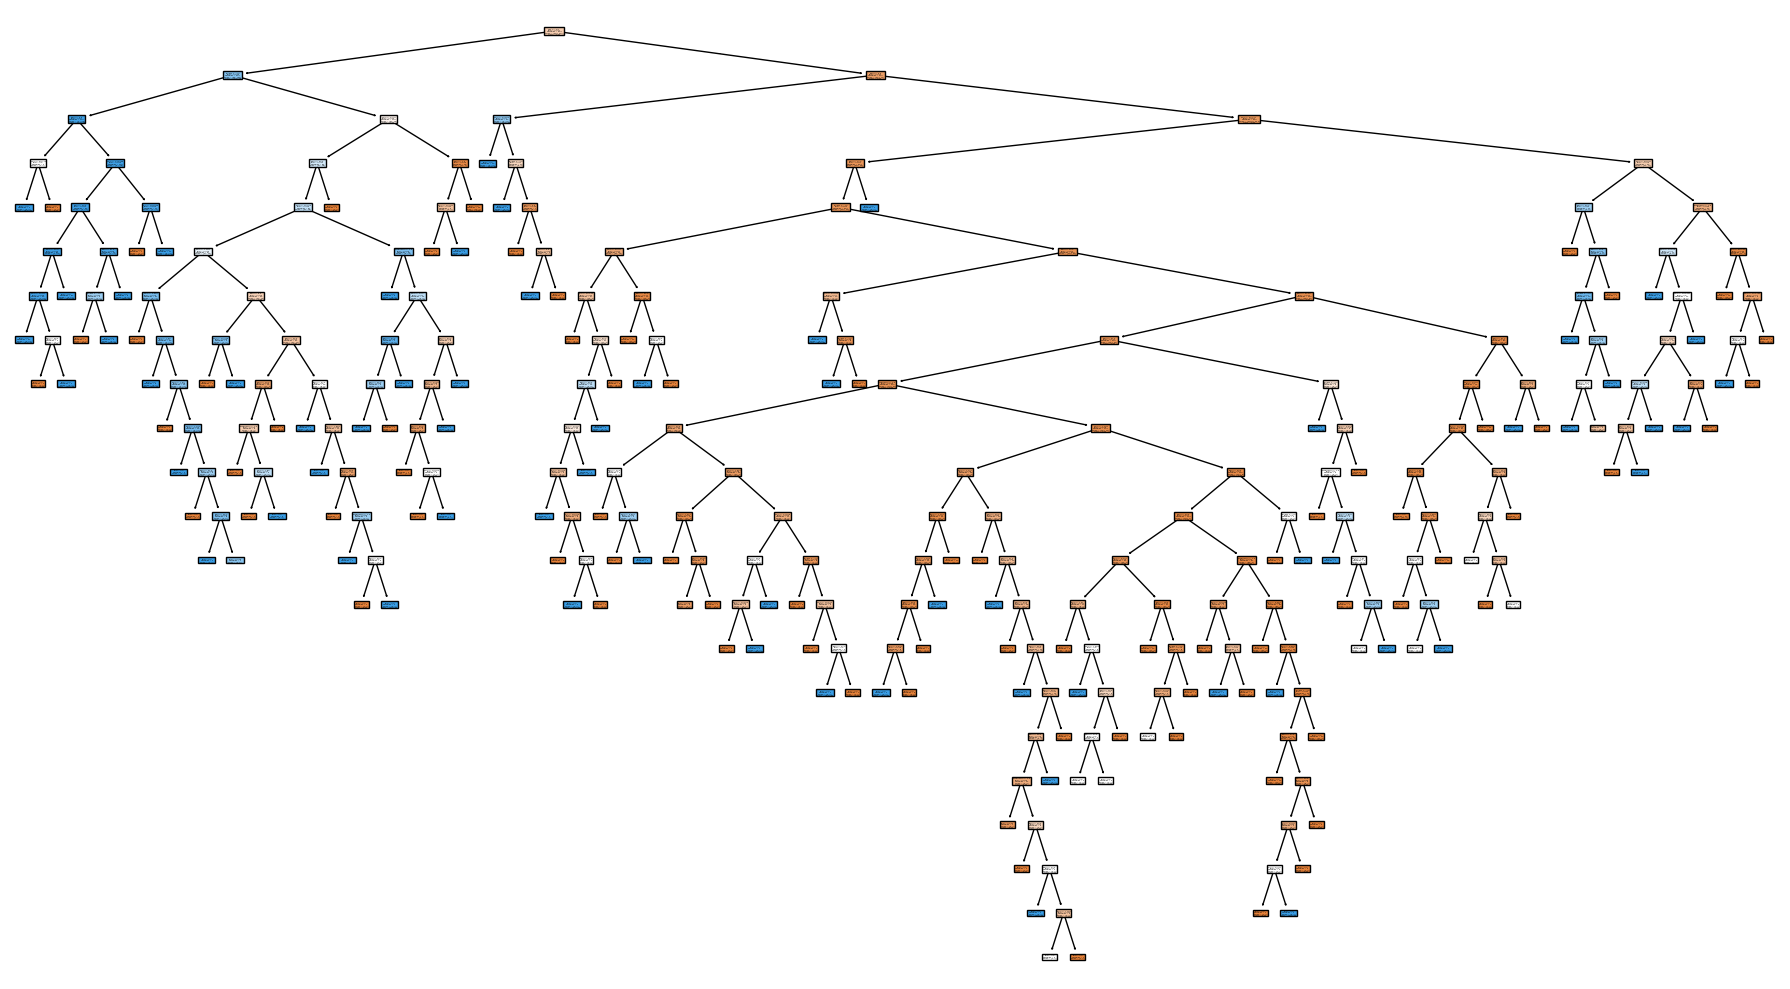

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [12]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True
)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

print("OOB score: ",rf.oob_score_ *100,"%")
print("testing accuracy: ",accuracy_score(y_test,y_pred)*100,"%")

OOB score:  80.89887640449437 %
testing accuracy:  77.23880597014924 %


(891, 15)